# LBG ring-intercept: particle-filter belief with a range-limited sensor

The companion notebook `lbg_ring_intercept.ipynb` runs the same scenario
with **truth-state** access — the MCTS guard always knows where the
bandit is. That's a strong assumption: a guard at LEO with a real sensor
won't see the bandit until it crosses inside sensor range.

This notebook keeps the geometry the same but flips the information
model:

1. The guard has a **`RangeLimitedObservation`** sensor — it only sees
   the bandit's position when the bandit is closer than `sensor_range_m`.
2. The guard's belief is a **`ParticleFilterBelief`**, initialized
   *uniformly on the 2:1 RT-plane natural-motion ring*. A Kalman filter
   would have to collapse this prior onto the lady (the centroid of the
   ring) — a useless point estimate. The PF expresses the ring directly.
3. Both sides drift on natural motion (`ZeroControl`). The bandit
   wanders along its ring; the guard sits on its small ring near the
   lady. The only thing changing is the **belief** as the bandit
   crosses into and out of sensor range.

What you'll see: the particle cloud sits on the ring, then collapses
to a tight cluster the moment the first measurement lands, then tracks
the bandit while it's in view, then begins to spread back out under
process noise once the bandit drifts out of range. The pre-resample
**effective sample size** N_eff is the quantitative signature of that
collapse.

CPU-only, like the other LBG notebooks.

In [1]:
# Pin CPU device before importing JAX. On Apple Silicon `jax-mps` may
# auto-register and become the default; the float64 reference-orbit
# arrays would then hit MLX and error.
import os
os.environ['JAX_DEFAULT_DEVICE'] = 'cpu'

import sys
from pathlib import Path
_here = Path.cwd()
if (_here / 'src' / 'orbital_game').is_dir():
    _repo_root = _here
elif (_here.parent / 'src' / 'orbital_game').is_dir():
    _repo_root = _here.parent
else:
    raise RuntimeError(f'Could not locate orbital-game repo root from cwd={_here}')
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

%load_ext autoreload
%autoreload 2

from types import SimpleNamespace

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

from orbital_game import (
    Actions, BySide, OrbitalGameEnv, ScenarioConfig, Side, VehicleParamsSpec,
)
from orbital_game.belief import (
    ParticleFilterBeliefUpdater, ParticleFilterRingInitializer,
)
from orbital_game.dynamics.hcw import hcw_rt_step
from orbital_game.games.lady_bandit_guard import LadyBanditGuard
from orbital_game.observations.range_limited import RangeLimitedObservation
from orbital_game.policies.zero import ZeroControl
from orbital_game.reference_orbit import (
    ReferenceOrbitState, mean_motion as ref_mean_motion,
)
from orbital_game.registry import DynamicsKey, StateComponentKey
from orbital_game.sampling.mass import ConstantMass
from orbital_game.sampling.side import RelativeEllipse
from orbital_game.sampling.spec import ICSpec

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Platform 'mps' is experimental and not all JAX functionality may be correctly supported!


## 1. Scenario

1 guard on a small ring (200 m) around the lady, 1 bandit on the
outer 2:1 RT-plane natural-motion ring (radial 2 km, along-track 4 km).
Both sides on HCW-RT dynamics, both running `ZeroControl` so the
trajectories are pure natural motion. Sensor range 2200 m — chosen
tight enough that the bandit, started at the max-distance phase
(π/2, distance 4000 m from the lady), is **out of range at t=0**
and only enters the sensor cone after roughly a quarter of an orbit.

The PF process noise on position is 1 m² / step and on velocity is
10⁻³ (m/s)² / step — small numbers that let the cloud follow the
natural-motion ring under predict, and only spread perceptibly when
the cloud gets resampled.

In [2]:
RING_RADIUS_M = 2000.0
GUARD_RING_RADIUS_M = 200.0
SENSOR_RANGE_M = 2200.0       # bandit at π/2 starts ~4000 m — out of range
SIGMA_RANGE = 5.0             # measurement std (m) on position when visible
DT = 10.0
MAX_HORIZON_S = 4500.0        # ~75 min — just over an orbital period
N_PARTICLES = 256
PROCESS_NOISE_DIAG = jnp.array([1.0, 1.0, 1e-3, 1e-3])  # (r, t, rdot, tdot)

ref_orbit = ReferenceOrbitState(
    position_eci=jnp.array([7000e3, 0.0, 0.0]),
    velocity_eci=jnp.array([0.0, 7.5e3, 0.0]),
)

def make_cfg(guard_obs_fn=None, bandit_obs_fn=None):
    return ScenarioConfig(
        n_guards=1, n_bandits=1,
        epoch_mjd_utc=60067.0,
        reference_orbit=ref_orbit,
        guard_components=(StateComponentKey.RT, StateComponentKey.MASS),
        bandit_components=(StateComponentKey.RT, StateComponentKey.MASS),
        guard_params=VehicleParamsSpec(dry_mass_kg=12.0, isp_s=65.0, max_thrust_n=3.6),
        bandit_params=VehicleParamsSpec(dry_mass_kg=12.0, isp_s=65.0, max_thrust_n=3.6),
        ic_sampler=ICSpec(
            guard_sampler=RelativeEllipse(
                radial_ellipse_m=GUARD_RING_RADIUS_M,
                cross_track_m=0.0, along_track_offset_m=0.0,
                phase_rad=jnp.array([0.0]),
                mass_sampler=ConstantMass(propellant_mass_kg=3.0),
            ),
            bandit_sampler=RelativeEllipse(
                radial_ellipse_m=RING_RADIUS_M,
                cross_track_m=0.0, along_track_offset_m=0.0,
                phase_rad=jnp.array([jnp.pi / 2.0]),  # max-distance phase
                mass_sampler=ConstantMass(propellant_mass_kg=3.0),
            ),
            validators=(), max_attempts=10,
        ),
        truth_dynamics=DynamicsKey.HCW_RT,
        policy_dynamics=DynamicsKey.HCW_RT,
        guard_observation_fn=guard_obs_fn,
        bandit_observation_fn=bandit_obs_fn,
        dt=DT, max_horizon_s=MAX_HORIZON_S, seed=0,
        game=LadyBanditGuard(breach_radius_m=5.0, catch_radius_m=50.0),
    )

# Build a proto config to read .layout, then attach observation fns.
proto_layout = OrbitalGameEnv(make_cfg()).layout
guard_obs_fn = RangeLimitedObservation(
    layout=proto_layout, sensor_range_m=SENSOR_RANGE_M, sigma_range=SIGMA_RANGE,
)
bandit_obs_fn = RangeLimitedObservation(
    layout=proto_layout, sensor_range_m=SENSOR_RANGE_M, sigma_range=SIGMA_RANGE,
)
cfg = make_cfg(guard_obs_fn=guard_obs_fn, bandit_obs_fn=bandit_obs_fn)
env = OrbitalGameEnv(cfg)
n_motion = float(ref_mean_motion(cfg.reference_orbit))
print(f'mean motion = {n_motion:.4e} rad/s   '
      f'(orbital period ~ {2*np.pi/n_motion/60:.1f} min)')
print(f'sensor range = {SENSOR_RANGE_M:.0f} m   '
      f'bandit-to-lady distance at t=0 ≈ {2*RING_RADIUS_M:.0f} m')

mean motion = 1.0977e-03 rad/s   (orbital period ~ 95.4 min)
sensor range = 2200 m   bandit-to-lady distance at t=0 ≈ 4000 m


## 2. Initial belief — uniform on the bandit ring

`ParticleFilterRingInitializer` samples K particles uniformly along
the same NSROE-derived 2:1 RT ellipse used by `RelativeEllipse`. Each
particle gets the *natural-motion velocity* for its sampled phase, so
particles are themselves valid drift trajectories — the cloud stays on
the ring as it propagates under HCW.

Self-pair (the guard's belief about its own state) is delta-on-truth
with tiny jitter; only the **cross-pair** (the guard's belief about
the bandit) is ring-distributed. The mean of the cross-pair particles
starts very close to the lady — it's the centroid of the ring — but
that's just the first moment; the *cloud* is what carries the prior.

In [3]:
def per_vehicle_hcw_rt(x, u, dt):
    return hcw_rt_step(x[None, :], u[None, :],
                       SimpleNamespace(mean_motion=n_motion), dt)[0]

pf_updater = ParticleFilterBeliefUpdater(
    dynamics_fn=per_vehicle_hcw_rt,
    process_noise=jnp.diag(PROCESS_NOISE_DIAG),
    dt=cfg.dt,
    n_eff_threshold=0.5,        # default — standard SIR resample threshold
    resample_jitter_scale=0.05, # small post-resample jitter — mitigates impoverishment
)
pf_initializer = ParticleFilterRingInitializer(
    layout=env.layout,
    ring_radius_m=RING_RADIUS_M,
    mean_motion_rad_s=n_motion,
    n_particles=N_PARTICLES,
)

# Reset env + initialize belief at t=0.
key0 = jax.random.PRNGKey(0)
key0, k_reset, k_init = jax.random.split(key0, 3)
state0, _ = env.reset(k_reset)
belief0 = pf_initializer(state0, Side.GUARD, k_init)

print('Belief shapes:')
print(f'  particles      {tuple(belief0.particles.shape)}   (N_obs, N_total, K, d)')
print(f'  log_weights    {tuple(belief0.log_weights.shape)}')
print(f'  n_eff          {tuple(belief0.n_eff.shape)}   initial = {float(belief0.n_eff[0, 1]):.0f}')
print(f'  weight_entropy {tuple(belief0.weight_entropy.shape)}   initial = {float(belief0.weight_entropy[0, 1]):.4f} (= log K = {np.log(N_PARTICLES):.4f})')
print(f'  resampled      {tuple(belief0.resampled.shape)}   initial = {bool(belief0.resampled[0, 1])}')

Belief shapes:
  particles      (1, 2, 256, 4)   (N_obs, N_total, K, d)
  log_weights    (1, 2, 256)
  n_eff          (1, 2)   initial = 256
  weight_entropy (1, 2)   initial = 5.5452 (= log K = 5.5452)
  resampled      (1, 2)   initial = False


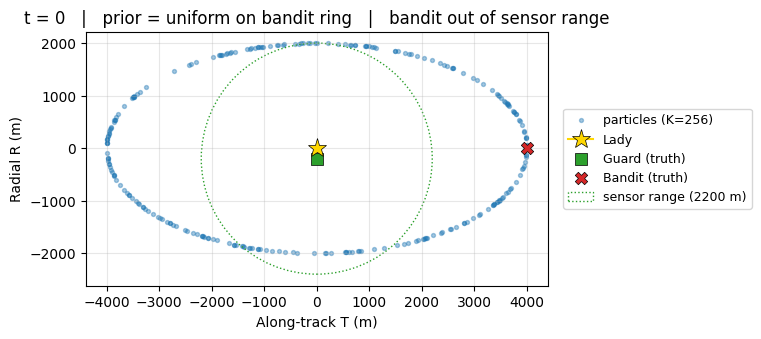

In [4]:
# Plot t=0: the ring of particles next to the bandit's true starting position.
fig, ax = plt.subplots(figsize=(7.5, 6.0), constrained_layout=True)

# (R, T) layout, plotted with T as horizontal, R as vertical — matches the
# other LBG notebook so the visual story is consistent.
p = np.asarray(belief0.particles[0, 1])  # cross-pair (guard, bandit), all K particles
ax.scatter(p[:, 1], p[:, 0], s=8, c='C0', alpha=0.4, label=f'particles (K={N_PARTICLES})')

g_truth = np.asarray(state0.guards.rt[0, :2])
b_truth = np.asarray(state0.bandits.rt[0, :2])
ax.plot(0, 0, marker='*', color='gold', markersize=14,
        markeredgecolor='black', markeredgewidth=0.5, label='Lady', zorder=5)
ax.scatter(g_truth[1], g_truth[0], s=80, c='C2', marker='s',
           edgecolors='black', linewidths=0.5, label='Guard (truth)', zorder=4)
ax.scatter(b_truth[1], b_truth[0], s=80, c='C3', marker='X',
           edgecolors='black', linewidths=0.5, label='Bandit (truth)', zorder=4)

# Sensor disc around the guard.
ax.add_patch(Circle((g_truth[1], g_truth[0]), SENSOR_RANGE_M,
                    fill=False, color='C2', linestyle=':', linewidth=1.0,
                    label=f'sensor range ({SENSOR_RANGE_M:.0f} m)'))

ax.set_xlabel('Along-track T (m)')
ax.set_ylabel('Radial R (m)')
ax.set_aspect('equal')
ax.set_title(f't = 0   |   prior = uniform on bandit ring   |   bandit out of sensor range')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9)
ax.grid(alpha=0.3)
plt.show()

## 3. Manual rollout with belief tracking

We could use `belief_rollout` (which scans the env step + belief update
together inside `jax.lax.scan`), but this notebook needs the per-step
belief snapshots in plain Python so we can visualize four key frames.
A manual loop is the cleanest way to keep both: stack the belief
trajectory after the loop and treat it like a `belief_history`.

In [5]:
guard_policy = ZeroControl(n_vehicles=cfg.n_guards, command_cls=env.guard_command_cls)
bandit_policy = ZeroControl(n_vehicles=cfg.n_bandits, command_cls=env.bandit_command_cls)

n_steps = int(cfg.max_horizon_s / cfg.dt)

key = jax.random.PRNGKey(7)
key, k_reset, k_init = jax.random.split(key, 3)
state, _ = env.reset(k_reset)
belief = pf_initializer(state, Side.GUARD, k_init)

states_over_time = [state]
beliefs_over_time = [belief]
guard_actions_list = []     # for stacking into a Trajectory for the animation
bandit_actions_list = []
visible_over_time = []      # bool: was the bandit visible to the guard this step?

for step in range(n_steps):
    key, k_g, k_b, k_env, k_obs, k_pf = jax.random.split(key, 6)
    g_action, _ = guard_policy(None, None, k_g, state.t)
    b_action, _ = bandit_policy(None, None, k_b, state.t)
    actions = Actions(sides=BySide(guard=g_action, bandit=b_action))
    step_out = env.step(k_env, state, actions)
    next_state = step_out.state

    # Guard's per-pair observation channels (post-step).
    obs_channels = env.guard_observation_fn(
        next_state, actions, Side.GUARD, env.config, k_obs, next_state.t,
    )
    belief = pf_updater(belief, obs_channels, g_action.dv, Side.GUARD, k_pf)

    state = next_state
    states_over_time.append(state)
    beliefs_over_time.append(belief)
    guard_actions_list.append(g_action)
    bandit_actions_list.append(b_action)
    # Cross-pair (observer 0, target 1) is the (guard, bandit) pair.
    visible_over_time.append(bool(obs_channels[0].visible[0, 1]))

n_eff_history = np.stack([np.asarray(b.n_eff) for b in beliefs_over_time], axis=0)
entropy_history = np.stack([np.asarray(b.weight_entropy) for b in beliefs_over_time], axis=0)
resampled_history = np.stack([np.asarray(b.resampled) for b in beliefs_over_time], axis=0)
visible_history = np.array(visible_over_time, dtype=bool)

first_detection_step = int(np.argmax(visible_history)) if visible_history.any() else -1
print(f'first detection step:        {first_detection_step}   '
      f'(t = {first_detection_step * cfg.dt:.0f} s)')
print(f'total visible steps:         {int(visible_history.sum())} / {n_steps}')
print(f'total resample events:       {int(resampled_history[:, 0, 1].sum())}   (cross-pair)')
print(f'N_eff cross-pair, min:       {float(n_eff_history[:, 0, 1].min()):.1f}')

first detection step:        110   (t = 1100 s)
total visible steps:         94 / 450
total resample events:       62   (cross-pair)
N_eff cross-pair, min:       1.0


## 4. Particle cloud at four key frames

We pick frames that tell the story: t=0 (uniform-on-ring prior),
mid-pre-detection (still ring, but rotated by natural motion), the
frame just after first detection (the cloud has just collapsed onto
the bandit), and mid-post-detection (the cloud is tracking the bandit
as it traverses the visible region). Each frame draws the truth
positions of guard and bandit, the sensor disc around the guard, and
the particle cloud.

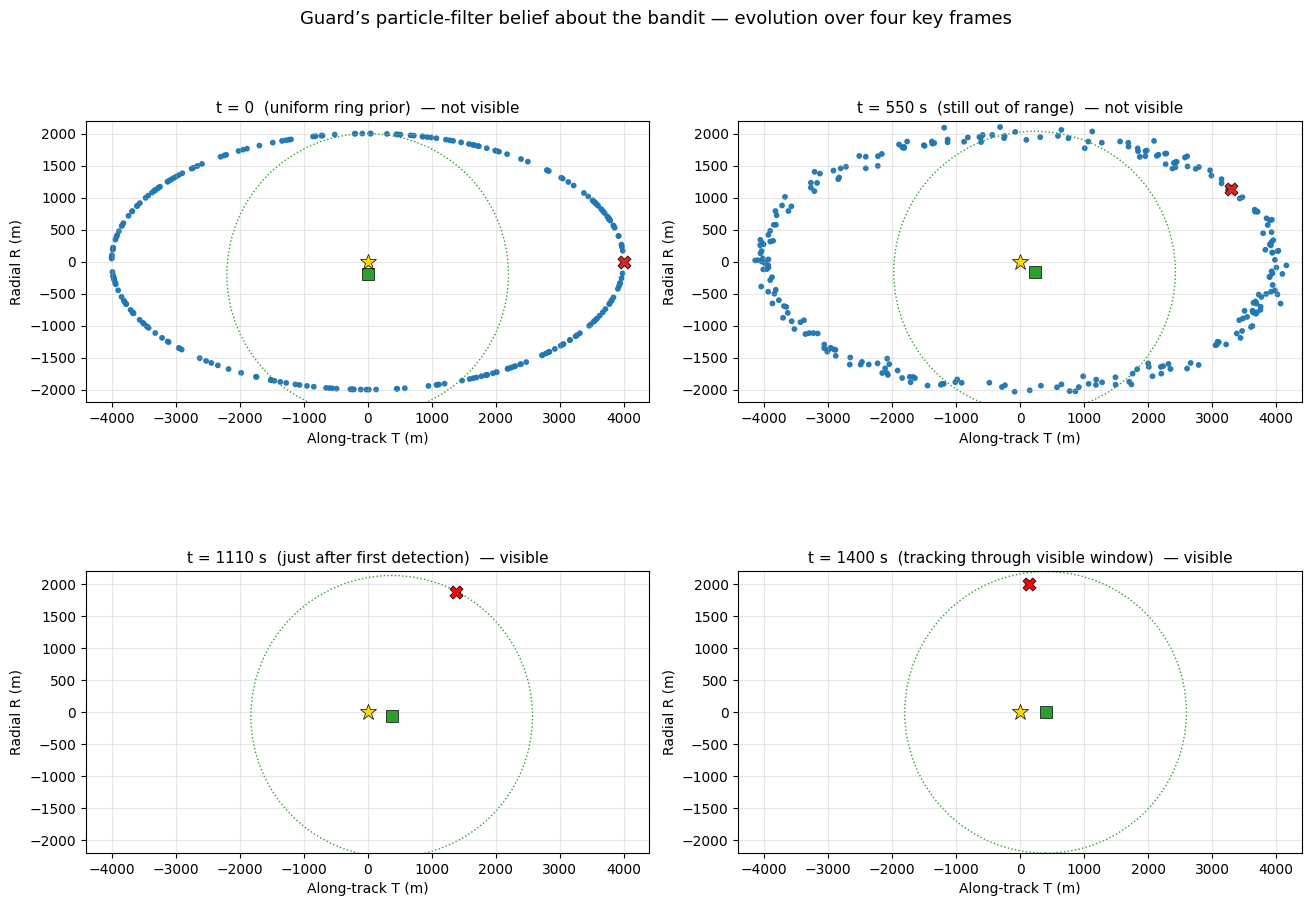

In [6]:
# Choose snapshot frames. Use first_detection_step as the anchor; if the
# bandit never gets detected in this seed, fall back to evenly-spaced.
if first_detection_step > 0:
    pre_detect_step = max(0, first_detection_step // 2)
    just_after = min(first_detection_step + 1, n_steps)
    far_after = min(first_detection_step + 30, n_steps)
    snapshot_steps = [0, pre_detect_step, just_after, far_after]
    snapshot_titles = [
        't = 0  (uniform ring prior)',
        f't = {pre_detect_step * cfg.dt:.0f} s  (still out of range)',
        f't = {just_after * cfg.dt:.0f} s  (just after first detection)',
        f't = {far_after * cfg.dt:.0f} s  (tracking through visible window)',
    ]
else:
    snapshot_steps = [0, n_steps // 3, 2 * n_steps // 3, n_steps]
    snapshot_titles = [f't = {s * cfg.dt:.0f} s' for s in snapshot_steps]

# Compute shared axis limits across all frames so the panels are directly
# comparable. Include the bandit ring extents so the prior fits.
pad = 1.1
xlim = (-2 * RING_RADIUS_M * pad, 2 * RING_RADIUS_M * pad)
ylim = (-RING_RADIUS_M * pad, RING_RADIUS_M * pad)

fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)

for ax, step, title in zip(axes.flatten(), snapshot_steps, snapshot_titles, strict=True):
    b_at = beliefs_over_time[step]
    s_at = states_over_time[step]
    p = np.asarray(b_at.particles[0, 1])  # (K, 4) cross-pair
    log_w = np.asarray(b_at.log_weights[0, 1])
    w = np.exp(log_w - log_w.max())
    w = w / w.sum()
    # Use weight → alpha so high-weight particles stand out post-collapse.
    alphas = np.clip(0.05 + 0.9 * (w / (w.max() + 1e-12)), 0.05, 0.95)
    ax.scatter(p[:, 1], p[:, 0], s=10, c='C0', alpha=alphas)

    g_truth = np.asarray(s_at.guards.rt[0, :2])
    b_truth = np.asarray(s_at.bandits.rt[0, :2])
    visible_now = (step > 0) and bool(visible_history[step - 1])

    ax.plot(0, 0, marker='*', color='gold', markersize=12,
            markeredgecolor='black', markeredgewidth=0.5, zorder=5)
    ax.scatter(g_truth[1], g_truth[0], s=80, c='C2', marker='s',
               edgecolors='black', linewidths=0.5, zorder=4)
    ax.scatter(b_truth[1], b_truth[0], s=90,
               c='red' if visible_now else 'C3', marker='X',
               edgecolors='black', linewidths=0.5, zorder=4)
    ax.add_patch(Circle((g_truth[1], g_truth[0]), SENSOR_RANGE_M,
                        fill=False, color='C2', linestyle=':', linewidth=1.0))

    ax.set_title(title + ('  — visible' if visible_now else '  — not visible'),
                 fontsize=11)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect('equal')
    ax.set_xlabel('Along-track T (m)')
    ax.set_ylabel('Radial R (m)')
    ax.grid(alpha=0.3)

fig.suptitle('Guard’s particle-filter belief about the bandit — evolution over four key frames',
             fontsize=13, y=1.03)
plt.show()

## 5. Collapse curve — N_eff and weight entropy over time

The two pre-resample metrics tell the same story on different scales:

- **N_eff** = $1 / \sum_i w_i^2$: literally the number of particles
  carrying meaningful weight. Uniform → K. Single-particle posterior
  → 1.
- **Weight entropy** = $-\sum_i w_i \log w_i$: Shannon entropy of the
  weight distribution, in nats. Uniform → log K ≈ 5.55 for K=256.
  Single-particle posterior → 0.

Both should sit at their uniform-maximum value for the entire
no-detection prefix, then drop sharply at the first detection step,
then settle into a moderate range as resampled particles distribute
along the visible-region likelihood. Resample events are marked as
vertical ticks at the bottom — they cluster around detection events.

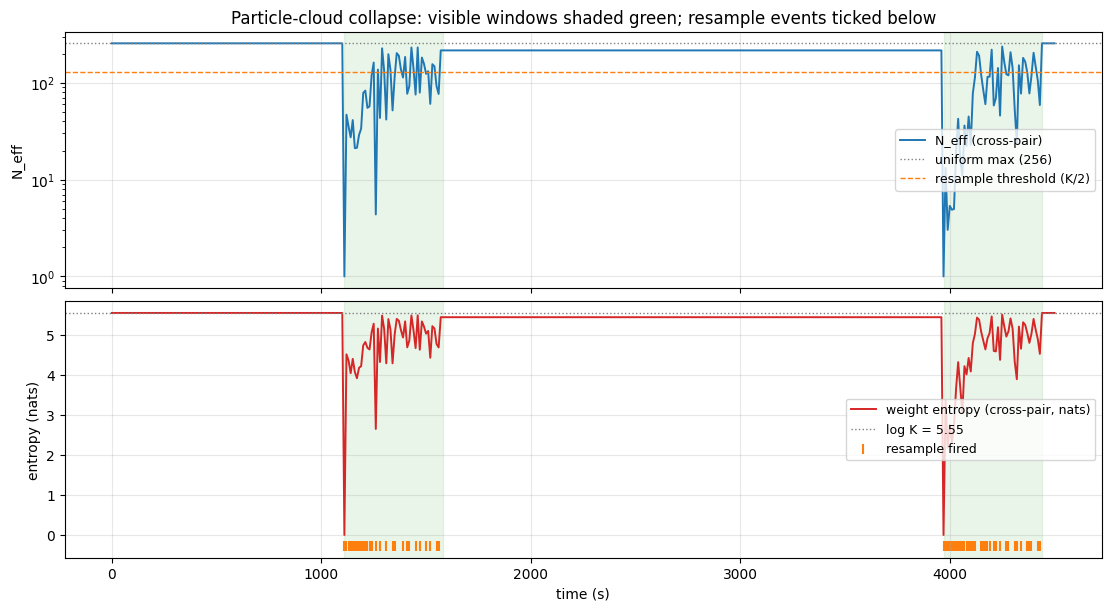

N_eff trace around first detection (step 110):
  step  108  t=  1080s  N_eff= 256.00  entropy= 5.545  resampled=False
  step  109  t=  1090s  N_eff= 256.00  entropy= 5.545  resampled=False
  step  110  t=  1100s  N_eff= 256.00  entropy= 5.545  resampled=False
  step  111  t=  1110s  N_eff=   1.00  entropy= 0.000  resampled=True  <-- first detection
  step  112  t=  1120s  N_eff=  46.89  entropy= 4.513  resampled=True
  step  113  t=  1130s  N_eff=  35.33  entropy= 4.356  resampled=True
  step  114  t=  1140s  N_eff=  27.38  entropy= 4.040  resampled=True
  step  115  t=  1150s  N_eff=  41.23  entropy= 4.398  resampled=True


In [7]:
t_axis = np.arange(len(beliefs_over_time)) * cfg.dt  # seconds
n_eff_xpair = n_eff_history[:, 0, 1]
ent_xpair = entropy_history[:, 0, 1]
resamp_xpair = resampled_history[:, 0, 1]

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True, constrained_layout=True)

ax = axes[0]
ax.plot(t_axis, n_eff_xpair, color='C0', linewidth=1.4, label='N_eff (cross-pair)')
ax.axhline(N_PARTICLES, color='C7', linestyle=':', linewidth=1, label=f'uniform max ({N_PARTICLES})')
ax.axhline(N_PARTICLES * 0.5, color='C1', linestyle='--', linewidth=1,
           label='resample threshold (K/2)')
# Shade visible windows so the relationship between visibility and N_eff is obvious.
vis = visible_history.astype(int)
vis_pad = np.concatenate([[0], vis, [0]])
starts = np.where(np.diff(vis_pad) == 1)[0]
ends = np.where(np.diff(vis_pad) == -1)[0]
for s, e in zip(starts, ends, strict=True):
    ax.axvspan((s + 1) * cfg.dt, (e + 1) * cfg.dt, color='C2', alpha=0.10)
ax.set_ylabel('N_eff')
ax.set_yscale('log')
ax.set_title('Particle-cloud collapse: visible windows shaded green; resample events ticked below')
ax.legend(loc='center right', fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(t_axis, ent_xpair, color='C3', linewidth=1.4, label='weight entropy (cross-pair, nats)')
ax.axhline(np.log(N_PARTICLES), color='C7', linestyle=':', linewidth=1, label=f'log K = {np.log(N_PARTICLES):.2f}')
for s, e in zip(starts, ends, strict=True):
    ax.axvspan((s + 1) * cfg.dt, (e + 1) * cfg.dt, color='C2', alpha=0.10)
# Resample event ticks along the bottom.
resample_ts = t_axis[resamp_xpair.astype(bool)]
ax.scatter(resample_ts, np.full_like(resample_ts, ax.get_ylim()[0]),
           marker='|', color='C1', s=60, label='resample fired')
ax.set_xlabel('time (s)')
ax.set_ylabel('entropy (nats)')
ax.legend(loc='center right', fontsize=9)
ax.grid(alpha=0.3)

plt.show()

if first_detection_step > 0:
    print(f'N_eff trace around first detection (step {first_detection_step}):')
    window = slice(max(0, first_detection_step - 2), min(len(t_axis), first_detection_step + 6))
    for i in range(window.start, window.stop):
        marker = '  <-- first detection' if i == first_detection_step + 1 else ''
        print(f'  step {i:4d}  t={t_axis[i]:6.0f}s  N_eff={n_eff_xpair[i]:7.2f}  '
              f'entropy={ent_xpair[i]:6.3f}  resampled={bool(resamp_xpair[i])}{marker}')

## 6. Animated belief evolution — `RolloutScene` integration

The belief snapshots above are static. The same particle cloud
(plus truth markers and the sensor disc) animates frame-by-frame
through the standard `RolloutScene` viz. The renderer detects a
particle-filter belief by duck-typing — any belief that exposes
`particles` and `log_weights` arrays gets the scatter-cloud overlay;
KF/EKF beliefs (with `cov`) keep the existing 2σ ellipses. So a
single `belief_history` keyword serves both belief families.

To feed the renderer we stack the per-step belief snapshots and
actions into a JAX-pytree `Trajectory` plus a `BySide` belief history
(both with leading time axis). For scenarios driven by `belief_rollout`
this stacking happens automatically inside `jax.lax.scan`; here we do
it by hand because we wanted the per-step Python objects for the static
plots above.

Markers in the animation:

- **Faded blue dots** — particle cloud. Per-particle alpha tracks
  normalized weight, so post-collapse a single bright particle stands
  out from a dim sea.
- **Open blue circle** — `belief.mean` for the cross-pair (the guard's
  posterior mean estimate of the bandit position).
- **Filled blue square** — guard truth.
- **Filled red square** — bandit truth.
- **Dotted gray circle** — guard's range-limited sensor disc.
- **Black star** — lady (RTN origin / reference orbit).

In [8]:
from orbital_game.env.types import SideTrajectory, Trajectory
from orbital_game.viz.animation import RolloutScene, save_animation

# ---- Stack the manual-loop snapshots into a JAX-pytree Trajectory + belief_history.
# Drop the trailing state so frames align with actions (T frames, T actions).
states_for_traj = states_over_time[:-1]
beliefs_for_traj = beliefs_over_time[:-1]

env_state_stacked = jax.tree_util.tree_map(lambda *xs: jnp.stack(xs, axis=0), *states_for_traj)
guard_actions_stacked = jax.tree_util.tree_map(
    lambda *xs: jnp.stack(xs, axis=0), *guard_actions_list,
)
bandit_actions_stacked = jax.tree_util.tree_map(
    lambda *xs: jnp.stack(xs, axis=0), *bandit_actions_list,
)
guard_belief_stacked = jax.tree_util.tree_map(
    lambda *xs: jnp.stack(xs, axis=0), *beliefs_for_traj,
)

# Synthesize the SideTrajectory placeholders RolloutScene needs (it only reads
# `.action` for thrust quivers; obs/reward/done/policy_state aren't visualised).
T = guard_actions_stacked.dv.shape[0]
empty_obs = jnp.zeros((T, 1))  # placeholder; show_thrust=False keeps obs unused
zeros_T = jnp.zeros(T)
done_T = jnp.zeros(T, dtype=bool)

traj_for_anim = Trajectory(
    env_state=env_state_stacked,
    sides=BySide(
        guard=SideTrajectory(
            obs=empty_obs, action=guard_actions_stacked,
            reward=zeros_T, done=done_T, policy_state=None,
        ),
        bandit=SideTrajectory(
            obs=empty_obs, action=bandit_actions_stacked,
            reward=zeros_T, done=done_T, policy_state=None,
        ),
    ),
    episode_done=done_T,
    controlled_side=Side.GUARD,
)
# Bandit side has no PF belief in this demo — pass None so the renderer skips it.
belief_history_for_anim = BySide(guard=guard_belief_stacked, bandit=None)

scene = RolloutScene(
    traj=traj_for_anim,
    cfg=cfg,
    dt=cfg.dt,
    mode='2d',                        # RT-plane scenario
    show_trail=True,
    show_cubes=True,
    show_sensor_range=True,           # auto-reads from RangeLimitedObservation
    show_thrust=False,                # ZeroControl rollout — no Δv arrows
    show_belief=True,
    belief_history=belief_history_for_anim,
    belief_particle_size=6.0,
    belief_particle_alpha_min=0.04,
    belief_particle_alpha_max=0.7,
    title_prefix='LBG ring + PF — ',
    figsize=(8.0, 7.0),
)
print(f'frames = {scene.n_frames}, axis_limit = {scene.axis_limit_m:.0f} m, mode = {scene.resolved_mode}')

# Render to MP4. The `outputs/` directory is the convention used by the
# other LBG notebooks; it sits at the repo root.
out_dir = _repo_root / 'outputs'
out_dir.mkdir(exist_ok=True)
out_path = out_dir / 'lbg_ring_pf_intercept.mp4'
save_animation(scene, str(out_path), fps=12, dpi=110)
print(f'Saved animation to {out_path}')

from IPython.display import Video
Video(str(out_path), embed=False)

frames = 450, axis_limit = 4400 m, mode = 2d
Saved animation to /Users/duncan/repos/orbital-game/outputs/lbg_ring_pf_intercept.mp4


## 6. Summary

The PF expresses the prior "bandit is on the natural-motion ring at
uniform phase" exactly — a Gaussian belief cannot. Under predict-only
(no measurement), the cloud rides the ring forward in time; the
weighted mean is uninformative (it sits near the lady, the centroid),
but the *cloud* still represents the true uncertainty.

The first measurement collapses N_eff in one step — from K all the way
down to ~1 — because almost every particle's likelihood under the
tight `σ = 5 m` measurement is essentially zero. The systematic
resample then redraws the cloud at the surviving particle's
neighbourhood (with the configured jitter), so subsequent measurements
have a more diverse pool to reweight.

Once the bandit drifts back out of sensor range, no more
log-likelihood updates fire on the channel, the weights stay uniform,
N_eff stays at K, and the cloud propagates ballistically under HCW.
Process noise spreads it slightly — you can see this in the upper-right
panel as a slight thickening of the cloud relative to the prior — but
the cloud stays informative about the bandit's likely region until
the next detection.

Possible extensions:

- **Negative information**: when `visible=False` *and* a particle
  predicts the target should be inside sensor range, downweight it.
  This narrows the prior between detections without needing a
  measurement — a single flag on `ParticleFilterBeliefUpdater`.
- **POMCP-style particle MCTS**: replace `MCTSPolicy`'s root
  state with samples drawn from the cross-pair particles. The
  guard's tree search then explores branches weighted by the
  posterior over bandit states rather than a single point estimate.
- **Comparison with `EKFBeliefUpdater`**: rerun this same scenario
  with a Gaussian prior centred on the lady. The EKF's mean stays
  pinned near the centroid until the first detection — the same
  collapse moment, but a uselessly broad covariance representing
  the ring as a circle around the lady.